In [ ]:
!CUDA_VISIBLE_DEVICES=4,5,7,9

(4109, 6163, 3)


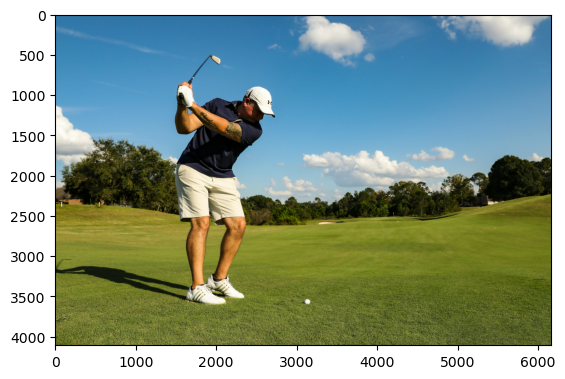

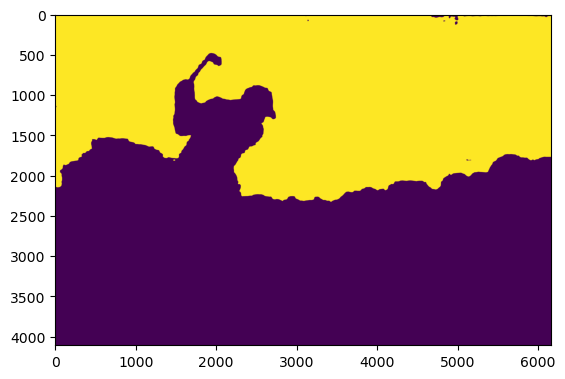

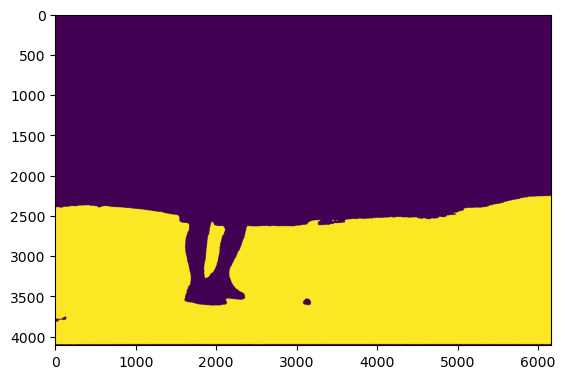

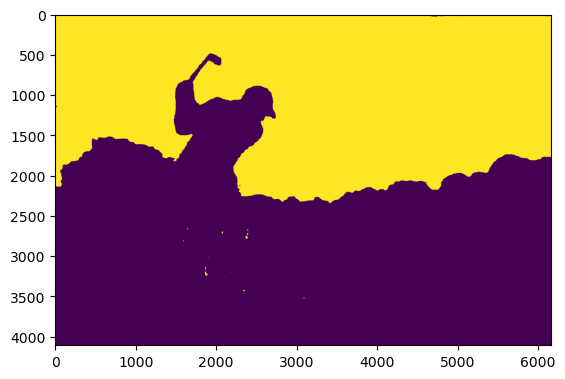

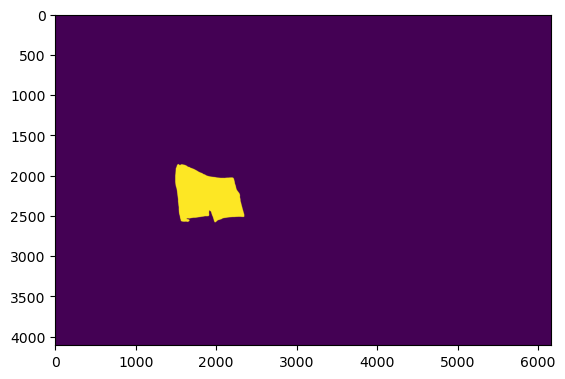

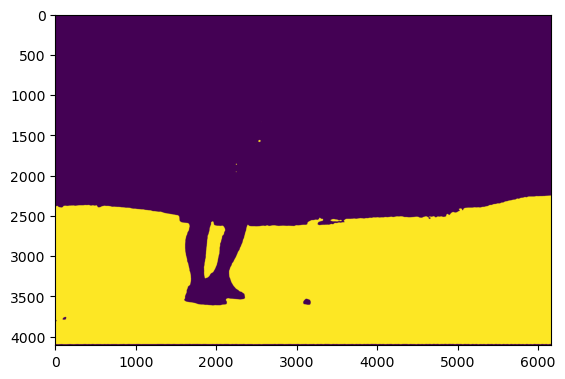

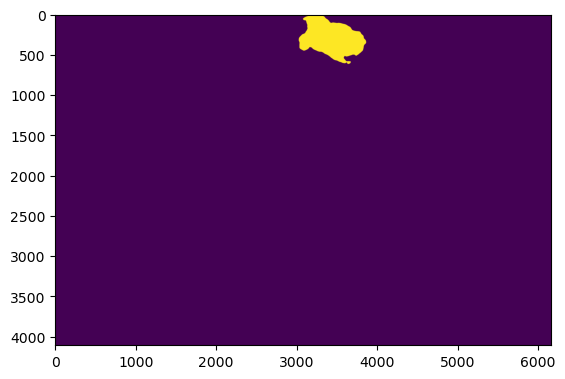

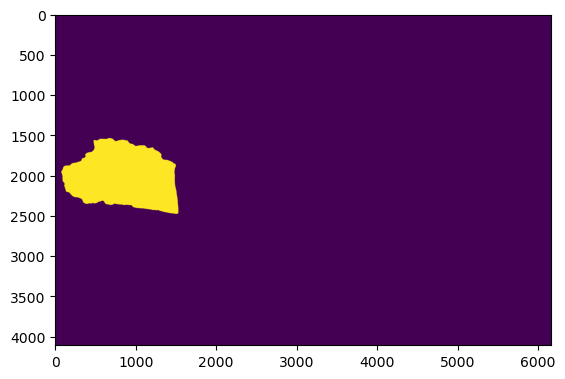

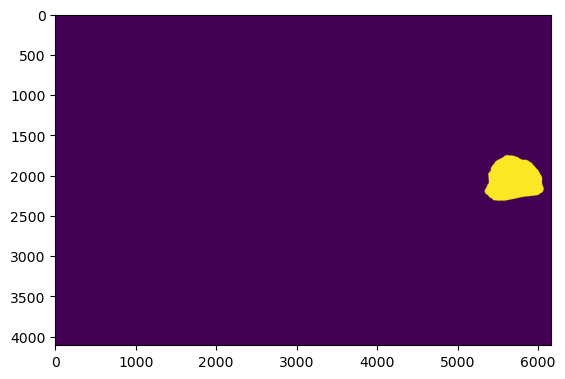

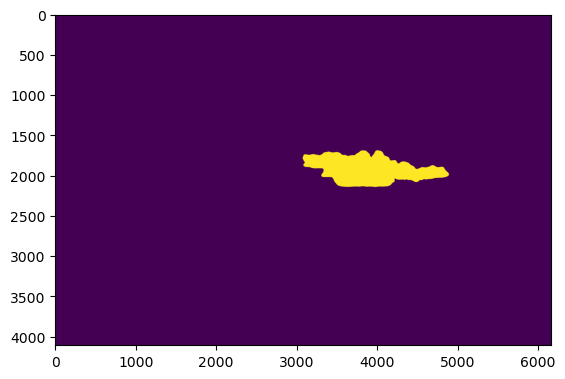

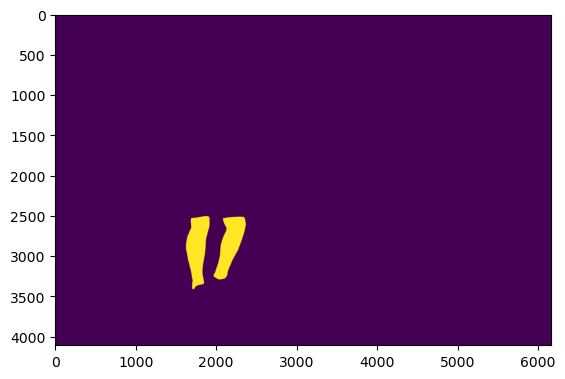

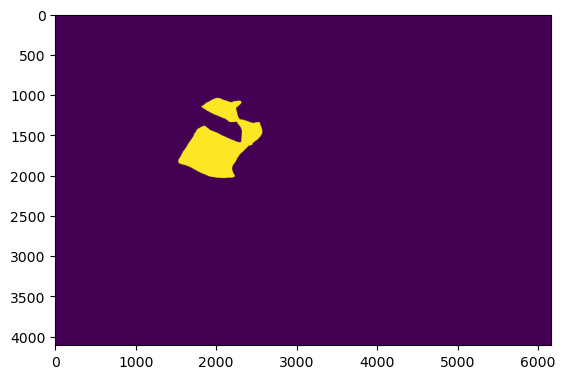

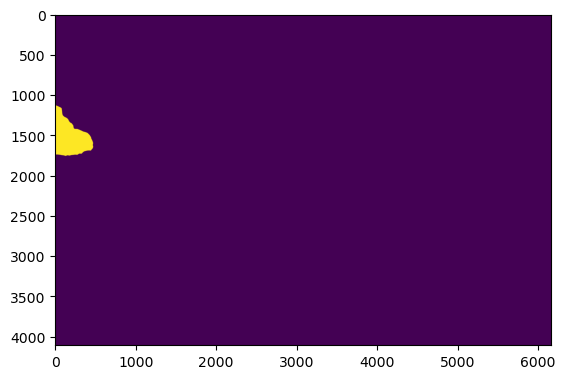

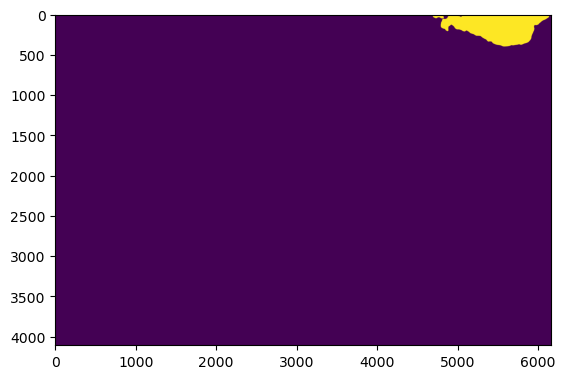

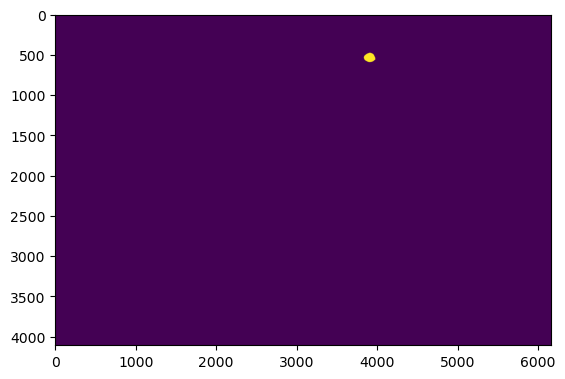

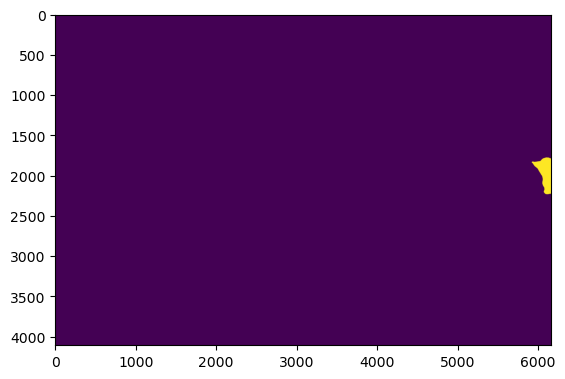

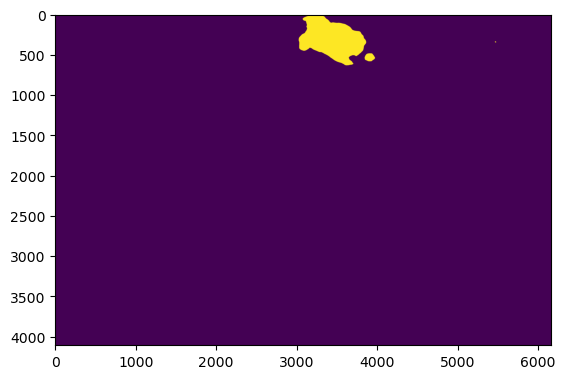

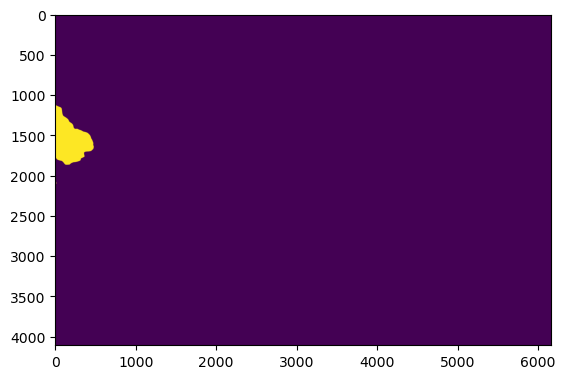

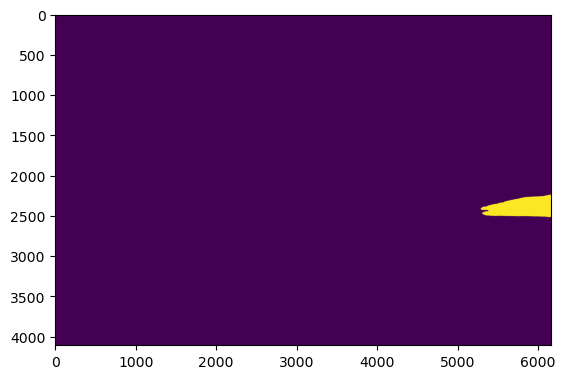

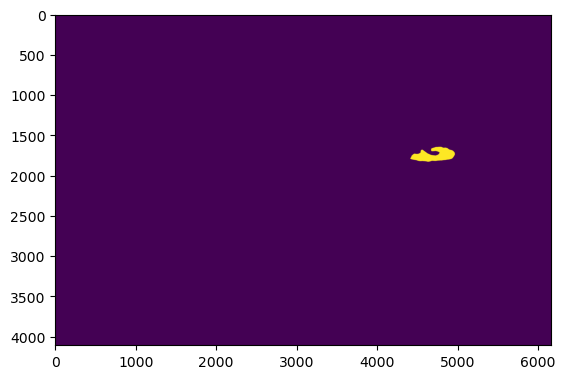

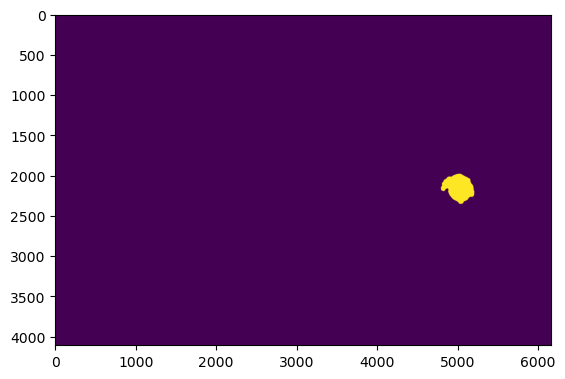

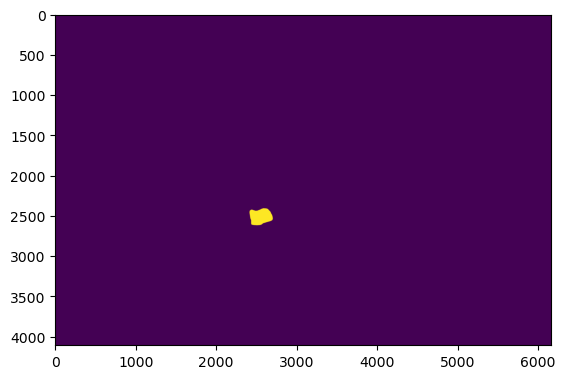

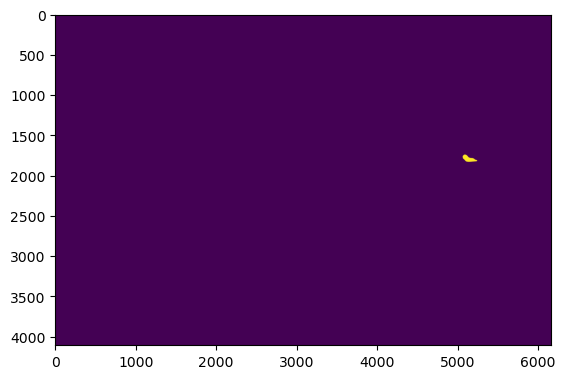

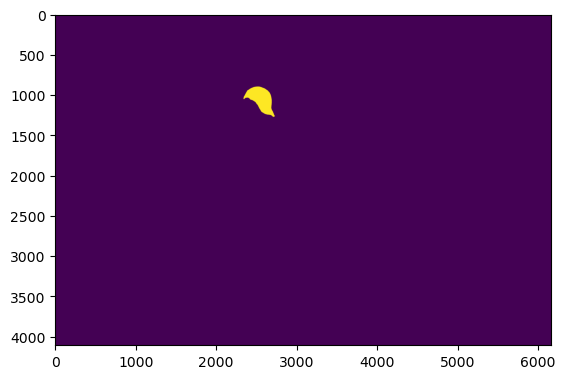

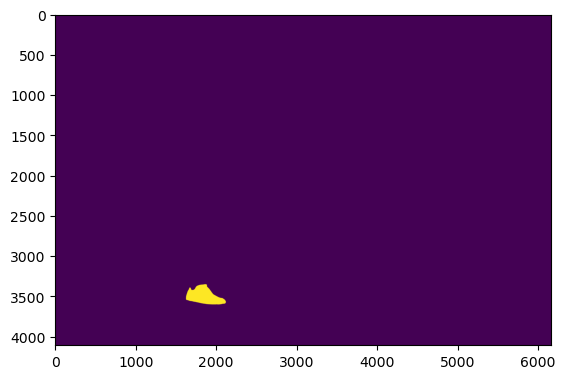

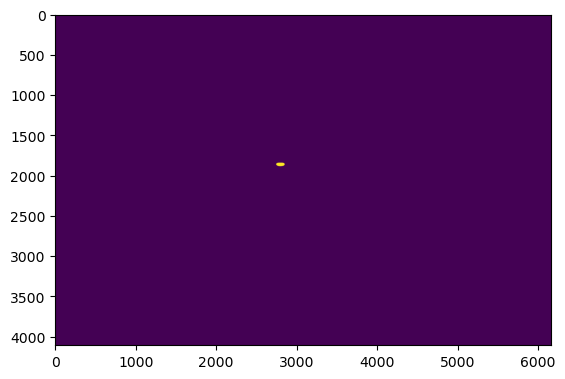

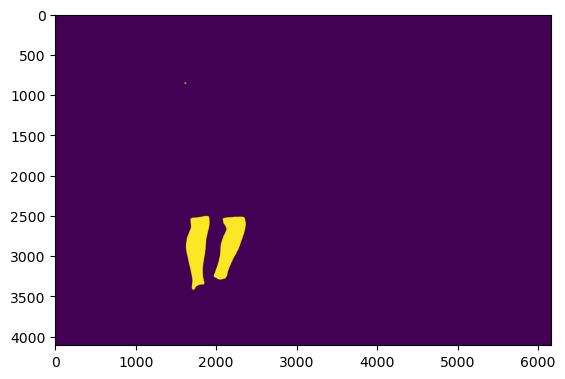

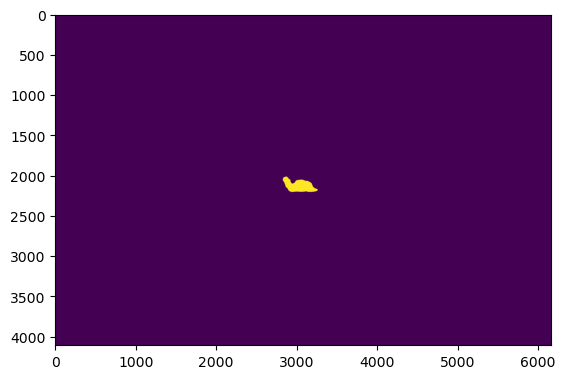

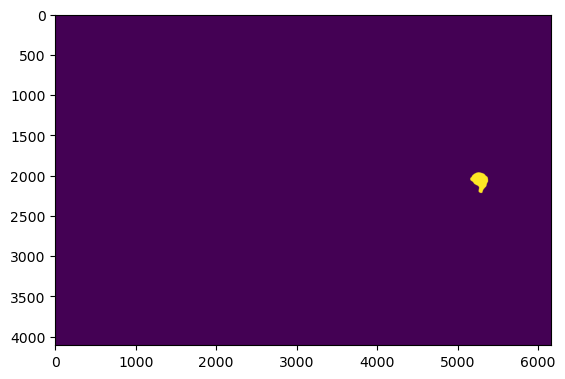

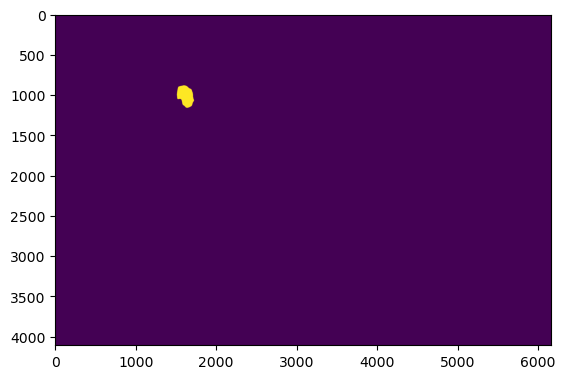

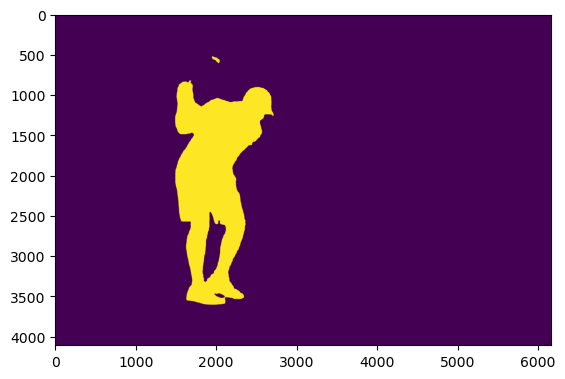

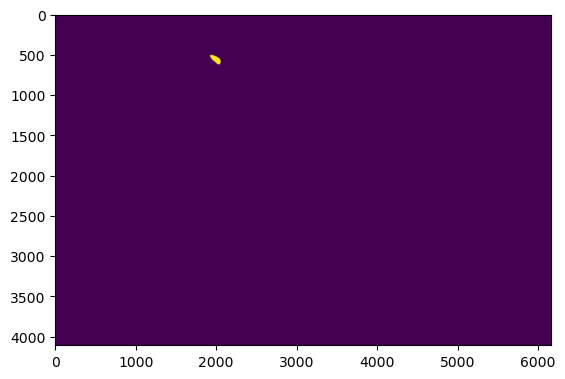

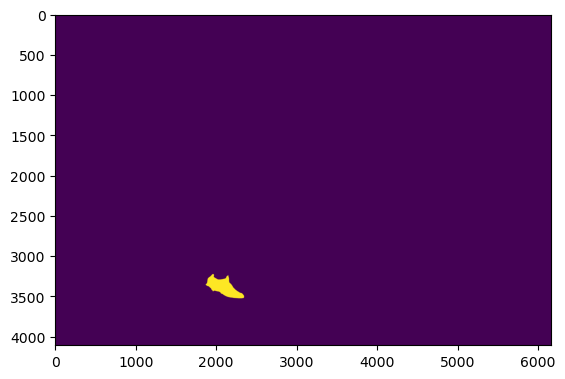

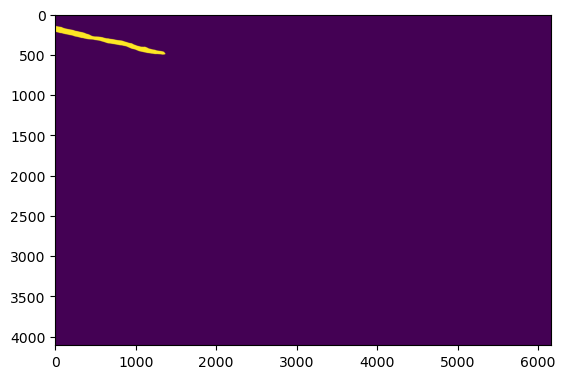

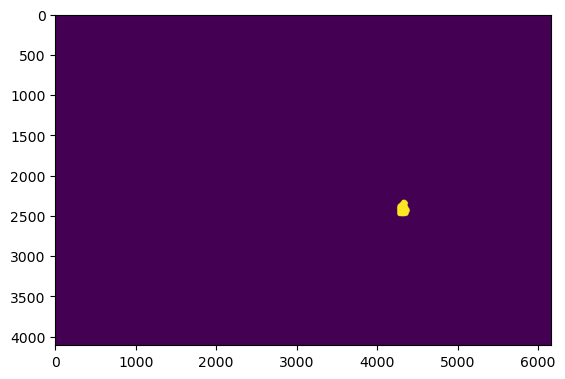

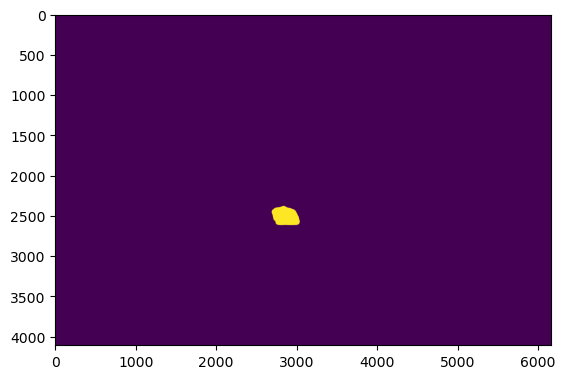

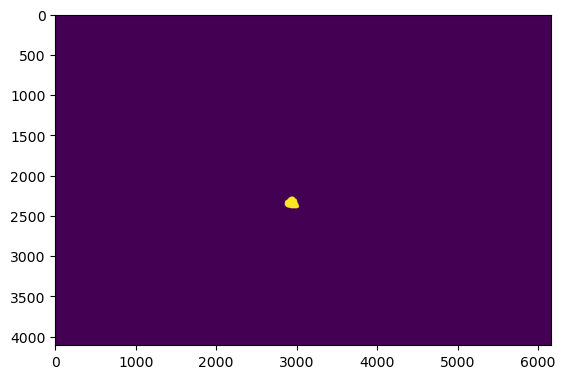

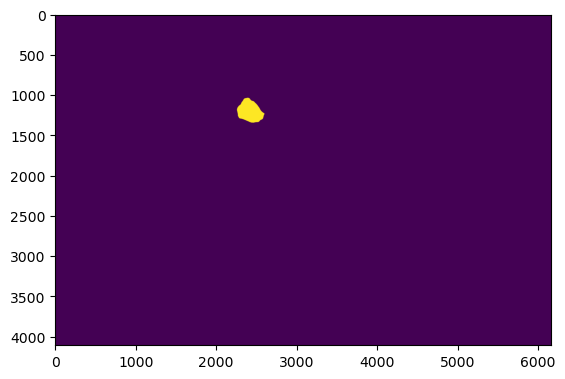

In [3]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '4,5,7,9'


img_path = '../data/debug/golf.jpg'
model_type = "vit_b"

if model_type == "vit_h":
    checkpoint_path = "../checkpoints/SAM/sam_vit_h_4b8939.pth"
elif model_type == "vit_l":
    checkpoint_path = "../checkpoints/SAM/sam_vit_l_0b3195.pth"
elif model_type == "vit_b":
    checkpoint_path = "../checkpoints/SAM/sam_vit_b_01ec64.pth"

# Load the image as a numpy array (BGR format by default)
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image.shape)

#visualize the image
plt.imshow(image)
plt.show()

sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
mask_generator = SamAutomaticMaskGenerator(sam)
masks = mask_generator.generate(image) 

#visualize the masks
plt.imshow(image)
for mask in masks:
    plt.imshow(mask['segmentation'])
    plt.show()


In [ ]:
!nvidia-smi

In [ ]:
from segment_anything import SamPredictor, sam_model_registry

img_path = '../data/debug/golf.jpg'
model_type = "vit_b"

if model_type == "vit_h":
    checkpoint_path = "../checkpoints/SAM/sam_vit_h_4b8939.pth"
elif model_type == "vit_l":
    checkpoint_path = "../checkpoints/SAM/sam_vit_l_0b3195.pth"
elif model_type == "vit_b":
    checkpoint_path = "../checkpoints/SAM/sam_vit_b_01ec64.pth"

# Load the image as a numpy array (BGR format by default)
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image.shape)

sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
predictor = SamPredictor(sam)
predictor.set_image(image)
masks, _, _ = predictor.predict(
)